In [4]:
import os
print(os.getcwd())          # shows your current working directory

C:\Users\PMLS\Desktop\MICROPLASTICS


In [7]:
from pathlib import Path

# Try these one by one until one works
candidate = './data'
p = Path(candidate)
if p.exists():
    print(f"\n✓ Found: {candidate}")
    for item in sorted(p.iterdir()):
        print(f"   {item.name}")
else:
    print(f"✗ Not found: {candidate}")


✓ Found: ./data
   0_train
   0_train_bi
   0_train_instance
   1_valid
   1_valid_bi
   1_valid_instance
   2_test
   2_test_bi
   2_test_instance


In [3]:
# Absolute check — see exactly where Python is looking
print("Looking in:", (ROOT / "0_train").resolve())
print("Folder exists:", (ROOT / "0_train").exists())

# List everything in that folder raw
import os
entries = os.listdir(ROOT / "0_train")
print(f"Total entries: {len(entries)}")
print("First 5 entries:", entries[:5])

Looking in: C:\Users\PMLS\Desktop\MICROPLASTICS\data\0_train
Folder exists: True
Total entries: 1531
First 5 entries: ['00000.jpg', '00001.jpg', '00002.jpg', '00004.jpg', '00010.jpg']


In [6]:
import os
from pathlib import Path
data = './data'
ROOT = Path(data)   # adjust to your extracted path
SPLITS = {
    "train": ("0_train", "0_train_bi", "0_train_instance"),
    "valid": ("1_valid", "1_valid_bi", "1_valid_instance"),
    "test":  ("2_test",  "2_test_bi",  "2_test_instance"),
}
for split, (img_dir, bi_dir, inst_dir) in SPLITS.items():
    imgs  = sorted((ROOT/img_dir).glob("*.jpg"))
    bis   = {p.stem for p in (ROOT/bi_dir).glob("*.jpg")}
    insts = {p.stem for p in (ROOT/inst_dir).glob("*.npz")}

    missing_bi   = [p.stem for p in imgs if p.stem not in bis]
    missing_inst = [p.stem for p in imgs if p.stem not in insts]

    print(f"[{split}]  images={len(imgs)}  "
          f"binary={len(bis)}  instance={len(insts)}")
    if missing_bi:
        print(f"  MISSING binary masks: {missing_bi[:5]}")
    if missing_inst:
        print(f"  MISSING instance masks: {missing_inst[:5]}")


[train]  images=1531  binary=1531  instance=1531
[valid]  images=202  binary=202  instance=202
[test]  images=202  binary=202  instance=202


In [8]:
import cv2
import numpy as np
from pathlib import Path

ROOT = Path('./data')

# Load one binary mask
bi_files = sorted((ROOT / "0_train_bi").glob("*.jpg"))
sample_bi = cv2.imread(str(bi_files[0]), cv2.IMREAD_GRAYSCALE)

print(f"File      : {bi_files[0].name}")
print(f"Shape     : {sample_bi.shape}")
print(f"Dtype     : {sample_bi.dtype}")
print(f"Min/Max   : {sample_bi.min()} / {sample_bi.max()}")
print(f"Unique values: {np.unique(sample_bi)}")

File      : 00000.jpg
Shape     : (1944, 2592)
Dtype     : uint8
Min/Max   : 0 / 255
Unique values: [  0   1   2   3   4   5   6   7 248 249 250 251 252 253 254 255]


In [25]:
import numpy as np
from pathlib import Path

ROOT = Path('./data')

npz_files = sorted((ROOT / "0_train_instance").glob("*.npz"))
sample = np.load(npz_files[1], allow_pickle=True)

print(f"File : {npz_files[1].name}")
print(f"Keys : {list(sample.keys())}")
print()

for key in sample.keys():
    arr = sample[key]
    print(f"  key     : '{key}'")
    print(f"  shape   : {arr.shape}")
    print(f"  dtype   : {arr.dtype}")
    print(f"  min/max : {arr.min()} / {arr.max()}")
    print(f"  unique  : {np.unique(arr)}")
    print()

File : 00001.npz
Keys : ['data']

  key     : 'data'
  shape   : (1944, 2592, 3)
  dtype   : uint16
  min/max : 0 / 255
  unique  : [  0   1   2   3   4   5   6   7 100 255]



In [32]:
import numpy as np
from pathlib import Path

ROOT = Path('./data')
npz_files = sorted((ROOT / "0_train_instance").glob("*.npz"))
data = np.load(npz_files[0], allow_pickle=True)['data']  # shape (H, W, 3)

print("Channel 0 unique values:", np.unique(data[:,:,0]))
print("Channel 1 unique values:", np.unique(data[:,:,1]))
print("Channel 2 unique values:", np.unique(data[:,:,2]))

# Count pixels per class in each channel
for ch in range(3):
    print(f"\nChannel {ch} value counts:")
    vals, counts = np.unique(data[:,:,ch], return_counts=True)
    for v, c in zip(vals, counts):
        print(f"  value={v:3d}  pixels={c:>10,}  ({100*c/data[:,:,ch].size:.1f}%)")

Channel 0 unique values: [  0 255]
Channel 1 unique values: [0]
Channel 2 unique values: [0 1 2]

Channel 0 value counts:
  value=  0  pixels= 5,036,531  (100.0%)
  value=255  pixels=     2,317  (0.0%)

Channel 1 value counts:
  value=  0  pixels= 5,038,848  (100.0%)

Channel 2 value counts:
  value=  0  pixels= 5,038,118  (100.0%)
  value=  1  pixels=       461  (0.0%)
  value=  2  pixels=       269  (0.0%)


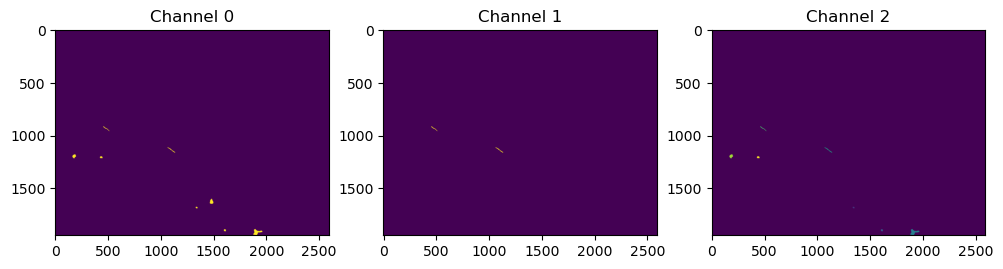

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(data[:,:,0])
plt.title("Channel 0")

plt.subplot(1,3,2)
plt.imshow(data[:,:,1])
plt.title("Channel 1")

plt.subplot(1,3,3)
plt.imshow(data[:,:,2])
plt.title("Channel 2")

plt.show()

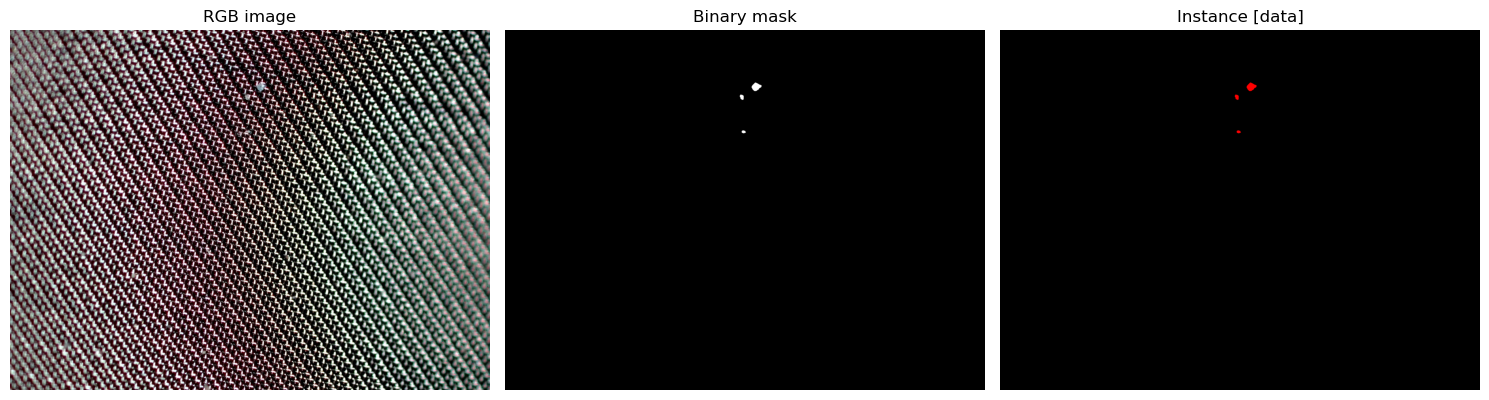

Saved → sanity_check.png


In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('./data')

# Load matching triplet by stem name
img_files = sorted((ROOT / "0_train").glob("*.jpg"))
first_stem = img_files[0].stem

img  = cv2.cvtColor(cv2.imread(str(ROOT/"0_train"/f"{first_stem}.jpg")), cv2.COLOR_BGR2RGB)
bi   = cv2.imread(str(ROOT/"0_train_bi"/f"{first_stem}.jpg"), cv2.IMREAD_GRAYSCALE)
inst = np.load(str(ROOT/"0_train_instance"/f"{first_stem}.npz"), allow_pickle=True)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img);               axes[0].set_title("RGB image");      axes[0].axis("off")
axes[1].imshow(bi, cmap="gray");   axes[1].set_title("Binary mask");    axes[1].axis("off")

# For instance — we'll plot the first key we find
first_key = list(inst.keys())[0]
axes[2].imshow(inst[first_key]);   axes[2].set_title(f"Instance [{first_key}]"); axes[2].axis("off")

plt.tight_layout()
plt.savefig("sanity_check.png", dpi=120)
plt.show()
print("Saved → sanity_check.png")

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('./data')

# Load matching triplet by stem name
img_files = sorted((ROOT / "0_train").glob("*.jpg"))
first_stem = img_files[0].stem

img  = cv2.cvtColor(cv2.imread(str(ROOT/"0_train"/f"{first_stem}.jpg")), cv2.COLOR_BGR2RGB)
bi   = cv2.imread(str(ROOT/"0_train_bi"/f"{first_stem}.jpg"), cv2.IMREAD_GRAYSCALE)
inst = np.load(str(ROOT/"0_train_instance"/f"{first_stem}.npz"), allow_pickle=True)

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img);               axes[0].set_title("RGB image");      axes[0].axis("off")
axes[1].imshow(bi, cmap="gray");   axes[1].set_title("Binary mask");    axes[1].axis("off")

# For instance — we'll plot the first key we find
first_key = list(inst.keys())[0]
axes[2].imshow(inst[first_key]);   axes[2].set_title(f"Instance [{first_key}]"); axes[2].axis("off")

plt.tight_layout()
plt.savefig("sanity_check.png", dpi=120)
plt.show()
print("Saved → sanity_check.png")